In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path1 = r'/Users/sevice/Desktop/project LL/scrap_per_month.csv'
path2 = r'/Users/sevice/Desktop/project LL/scrap_per_leader.csv'
path3 = r'/Users/sevice/Desktop/project LL/anomaly_boxes_per_month.csv'
path4 = r'/Users/sevice/Desktop/project LL/material_per_leader.csv'
path5 = r'/Users/sevice/Desktop/project LL/productivity_per_leader.csv'

df_scrap_month = pd.read_csv(path1)
df_scrap_leader = pd.read_csv(path2)
df_anomaly = pd.read_csv(path3)
df_material = pd.read_csv(path4)
df_productivity = pd.read_csv(path5)

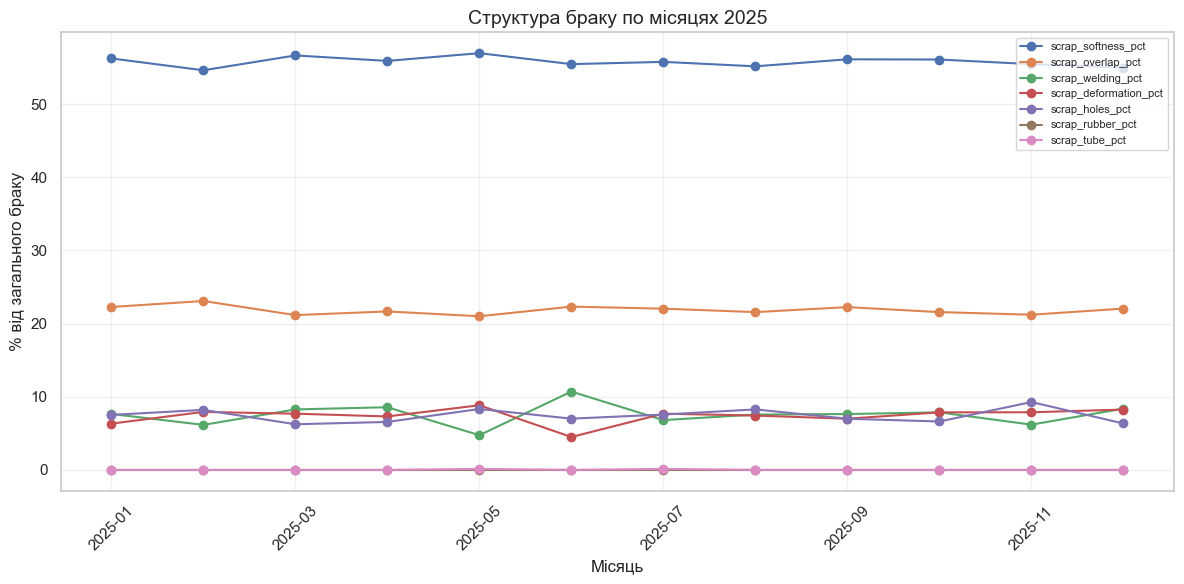

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

df_scrap_month.plot(
    x='month_1',
    y=['scrap_softness_pct', 'scrap_overlap_pct', 'scrap_welding_pct',
       'scrap_deformation_pct', 'scrap_holes_pct', 'scrap_rubber_pct', 'scrap_tube_pct'],
    ax=ax,
    marker='o'
)

ax.set_title('Структура браку по місяцях 2025', fontsize=14)
ax.set_xlabel('Місяць')
ax.set_ylabel('% від загального браку')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

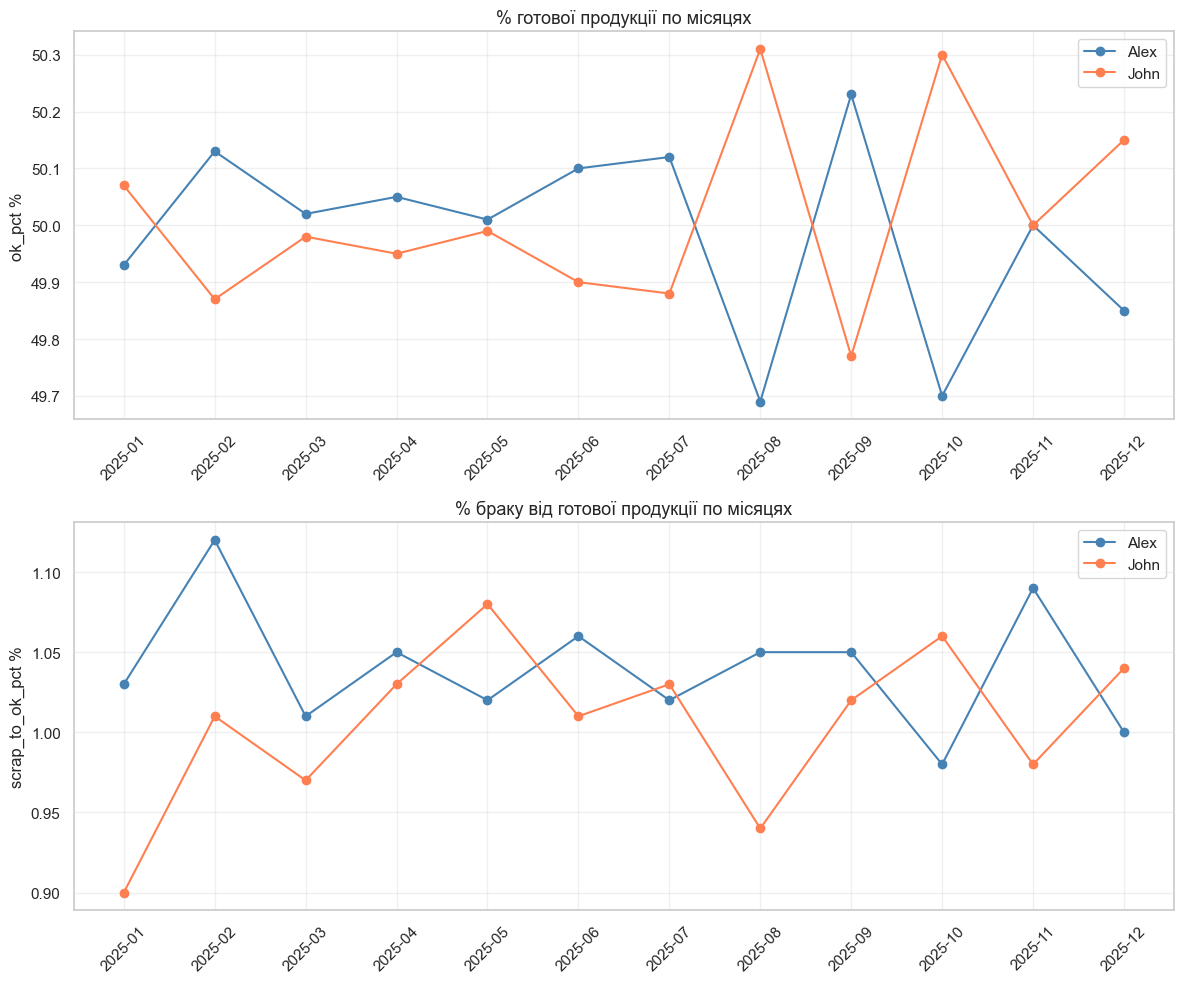

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

alex = df_productivity[df_productivity['team_leader'] == 'Alex']
john = df_productivity[df_productivity['team_leader'] == 'John']

# ok_pct
axes[0].plot(alex['month'], alex['ok_pct'], marker='o', label='Alex', color='steelblue')
axes[0].plot(john['month'], john['ok_pct'], marker='o', label='John', color='coral')
axes[0].set_title('% готової продукції по місяцях', fontsize=13)
axes[0].set_ylabel('ok_pct %')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# scrap_to_ok_pct
axes[1].plot(alex['month'], alex['scrap_to_ok_pct'], marker='o', label='Alex', color='steelblue')
axes[1].plot(john['month'], john['scrap_to_ok_pct'], marker='o', label='John', color='coral')
axes[1].set_title('% браку від готової продукції по місяцях', fontsize=13)
axes[1].set_ylabel('scrap_to_ok_pct %')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

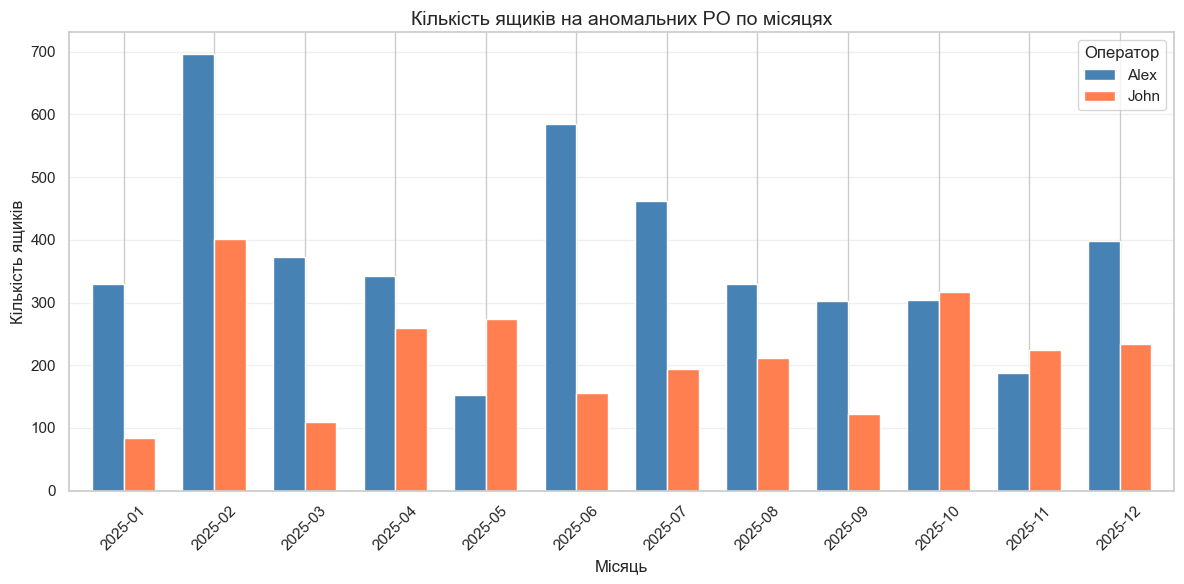

In [29]:
df_anomaly_pivot = df_anomaly.pivot(index='month', columns='scan_leader', values='boxes_scanned')

fig, ax = plt.subplots(figsize=(12, 6))

df_anomaly_pivot.plot(
    kind='bar',
    ax=ax,
    color=['steelblue', 'coral'],
    width=0.7
)

ax.set_title('Кількість ящиків на аномальних PO по місяцях', fontsize=14)
ax.set_xlabel('Місяць')
ax.set_ylabel('Кількість ящиків')
ax.legend(title='Оператор')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

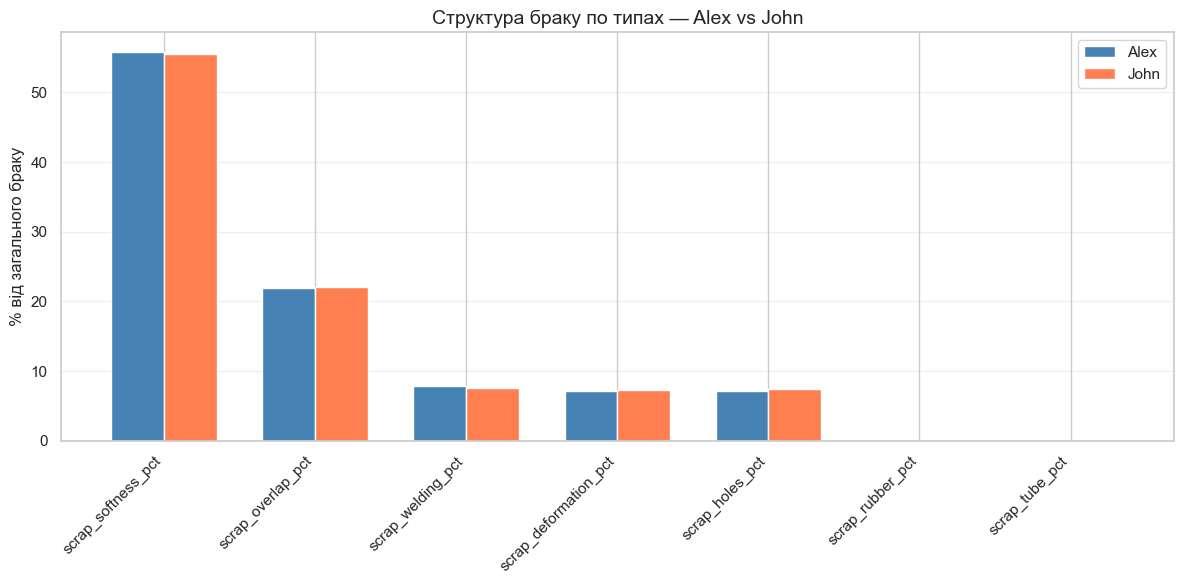

In [30]:
df_scrap_leader_melted = df_scrap_leader.melt(
    id_vars='scan_leader',
    var_name='scrap_type',
    value_name='pct'
)

fig, ax = plt.subplots(figsize=(12, 6))

scrap_types = df_scrap_leader.columns[1:].tolist()
x = range(len(scrap_types))
width = 0.35

alex_vals = df_scrap_leader[df_scrap_leader['scan_leader'] == 'Alex'].iloc[0, 1:].values
john_vals = df_scrap_leader[df_scrap_leader['scan_leader'] == 'John'].iloc[0, 1:].values

ax.bar([i - width/2 for i in x], alex_vals, width, label='Alex', color='steelblue')
ax.bar([i + width/2 for i in x], john_vals, width, label='John', color='coral')

ax.set_title('Структура браку по типах — Alex vs John', fontsize=14)
ax.set_ylabel('% від загального браку')
ax.set_xticks(x)
ax.set_xticklabels(scrap_types, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Висновки за результатами аналізу

Проаналізувавши структуру браку та роботу змін, можна виділити три головні моменти:

### 1. Що взагалі відбувається з браком?
Проблема на заводі системна. Протягом усього року картина взагалі не змінюється від місяця до місяця. 
Головна проблема — це **scrap_softness_pct** (дефекти м'якості), на які стабільно припадає понад 55% усього браку. Ще близько 22% — це **scrap_overlap_pct** (перекриття). 

**Висновок:** Якщо ми хочемо реально зменшити кількість відходів, треба розбиратися саме з м'якістю та перекриттям. Ці дві категорії сумарно дають майже 77% усього браку. Решта типів дефектів на цьому тлі майже невідчутні.

### 2. Як працюють Alex та John на фінальному етапі?
Якщо дивитися на сухі цифри готової продукції (таблиця df_productivity), то обидва тімлідери працюють однаково добре. Відсоток браку готового продукту у них обох стабільно тримається в межах норми (від 0.9% до 1.15%). На графіках видно, що вони йдуть абсолютно нарівні, періодично змінюючи один одного. Тобто до етапу фінальної збірки та контролю якості питань немає.

### 3. Де насправді ховається проблема (Root Cause)?
А от аналіз аномальних замовлень (df_anomaly) показав зовсім іншу картину. Коли ми взяли замовлення з найбільшим браком і подивилися, хто саме готував для них сировину, виявилося, що зміна **Alex** (як scan_leader) фігурує там постійно. 

У більшості місяців (особливо в лютому, червні та липні) кількість проблем